In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import sys
sys.path.append("../src")

from lstm_models import (
    build_univariate_lstm,
    build_multivariate_lstm,
    build_encoder_decoder
)

In [3]:
df = pd.read_csv("../data/processed/player_transfer_value_with_sentiment.csv")

df.head()

,player_name,season,season_encoded,team,position,position_encoded,current_age,market_value_eur,log_market_value,market_value_tier_encoded,...,transfer_attractiveness_score,vader_positive_score,vader_negative_score,vader_compound_score,tb_polarity,tb_subjectivity,positive_count,negative_count,neutral_count,sentiment_label
0,Lionel Andrés Messi Cuccittini,2019/20,1,Barcelona,Forward,4,25,67500000.0,18.0276,4,...,88.0797,0.1733,0.1283,0.0921,0.1200,0.7767,2,1,0,Positive
1,Antoine Griezmann,2019/20,1,Barcelona,Forward,4,25,37500000.0,17.4399,3,...,81.7368,0.0603,0.1353,-0.1510,0.3083,0.3833,0,2,1,Negative
2,Ousmane Dembélé,2019/20,1,Barcelona,Midfielder,3,25,19500000.0,16.7859,2,...,80.1995,0.1720,0.0853,0.2107,0.2944,0.5167,1,0,2,Positive
3,Anssumane Fati,2019/20,1,Barcelona,Midfielder,3,25,13500000.0,16.4182,2,...,81.6069,0.1080,0.1527,-0.1527,-0.2333,0.0667,1,2,0,Negative
4,Pedro González López,2019/20,1,Barcelona,Defender,2,25,16500000.0,16.6189,2,...,76.7660,0.0613,0.1893,-0.1332,0.2333,0.6593,1,2,0,Negative


In [4]:
df["log_market_value"] = np.log1p(df["market_value_eur"])

In [5]:
df = df.sort_values(["player_name","season_encoded"])

In [6]:
features = [
    "log_market_value",
    "attacking_output_index",
    "injury_burden_index",
    "availability_rate",
    "vader_compound_score",
    "social_buzz_score"
]

data = df[features]

In [7]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [8]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length,0])

    return np.array(X), np.array(y)

In [9]:
seq_length = 3

X_all = []
y_all = []

for player in df["player_name"].unique():

    player_df = df[df["player_name"] == player]

    player_features = scaler.transform(player_df[features])

    if len(player_features) > seq_length:

        X_tmp, y_tmp = create_sequences(player_features, seq_length)

        X_all.append(X_tmp)
        y_all.append(y_tmp)

X = np.vstack(X_all)
y = np.hstack(y_all)

print(X.shape)
print(y.shape)

(2000, 3, 6)
(2000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
market_values = df[["log_market_value"]].values

X_uni, y_uni = create_sequences(market_values, seq_length)

model_uni = build_univariate_lstm(seq_length)

history_uni = model_uni.fit(
    X_uni,
    y_uni,
    epochs=40,
    batch_size=8,
    validation_split=0.2
)

d:\TransferIQ\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 26.7565 - val_loss: 0.8525
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7009 - val_loss: 0.6053
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5746 - val_loss: 0.4960
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5009 - val_loss: 0.4388
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4539 - val_loss: 0.6088
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4594 - val_loss: 0.4856
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4485 - val_loss: 0.4196
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4439 - val_loss: 0.4116
Epoch 9/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4360 - val_loss: 0.4081
Epoch 10/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4228 - val_loss: 0.4317
Epoch 11/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4348 - val_loss: 0.3955
Epoch 12/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

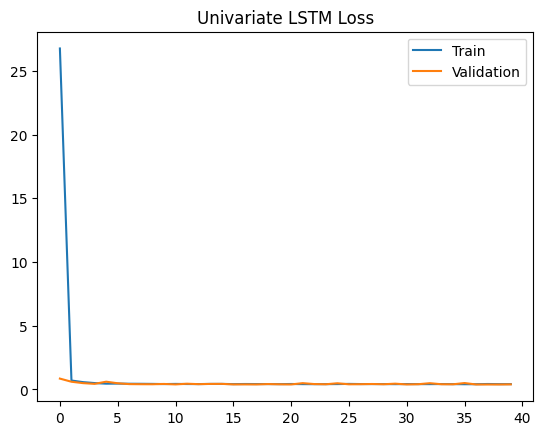

In [12]:
plt.plot(history_uni.history["loss"])
plt.plot(history_uni.history["val_loss"])

plt.title("Univariate LSTM Loss")
plt.legend(["Train","Validation"])

plt.show()

In [20]:
n_features = X.shape[2]

model_multi = build_multivariate_lstm(
    seq_length,
    n_features
)

history_multi = model_multi.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2
)

final_loss = history_multi.history['loss'][-1]
print("Final Training Loss:", final_loss)

Epoch 1/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0283 - val_loss: 0.0025
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.7161e-04 - val_loss: 3.5635e-04
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9584e-04 - val_loss: 2.4550e-04
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.9757e-04 - val_loss: 2.0929e-04
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5827e-04 - val_loss: 1.9232e-04
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4158e-04 - val_loss: 1.7835e-04
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1563e-04 - val_loss: 2.1348e-04
Epoch 8/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1005e-04 - val_loss: 2.0626e-04
Epoch 9/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2397e-04 - val_loss: 2.7450e-04
Epoch 10/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0808e-04 - val_loss: 1.4158e-04
Epoch 11/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7360

In [14]:
pred = model_multi.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [15]:
pred_rescaled = scaler.inverse_transform(
    np.concatenate((pred, np.zeros((pred.shape[0], len(features)-1))), axis=1)
)[:,0]

y_rescaled = scaler.inverse_transform(
    np.concatenate((y_test.reshape(-1,1), np.zeros((y_test.shape[0], len(features)-1))), axis=1)
)[:,0]

pred_actual = np.expm1(pred_rescaled)
y_actual = np.expm1(y_rescaled)

In [16]:
rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
mae = mean_absolute_error(y_actual, pred_actual)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3068812.3602445754
MAE: 1526637.4000690402


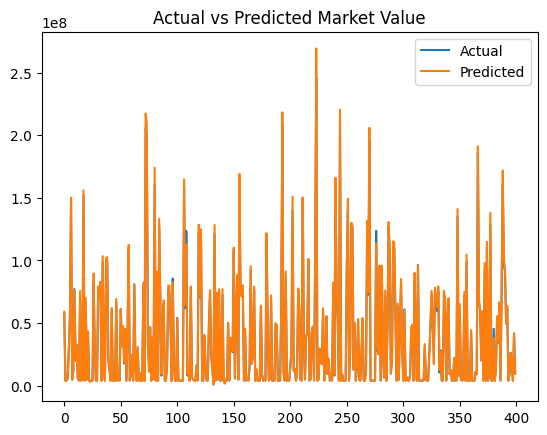

In [17]:
plt.plot(y_actual,label="Actual")
plt.plot(pred_actual,label="Predicted")

plt.title("Actual vs Predicted Market Value")

plt.legend()

plt.show()

In [18]:
future_steps = 2

model_enc = build_encoder_decoder(
    seq_length,
    n_features,
    future_steps
)

model_enc.fit(
    X,
    y,
    epochs=30,
    batch_size=8
)

Epoch 1/30


d:\TransferIQ\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0811
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0521
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0515
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0511
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0512
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0512
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0510
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0508
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0509
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0503
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0509
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0506
Epoch 13/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0509
Epoch 14/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0510
Epoch 15/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0510


In [19]:
model_multi.save("../dashboard/lstm_model.h5")